**Ariel Pan, Daniel Lyu**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Week 4: Train ConvPCNs on CIFAR-10

The focus of this week is to train several ConvPCN nets and analyze the effect of He/Kaiming initialization and Group Normalization. Finally, you will train a deeper ConvPCN to strive for high classification accuracy on CIFAR-10 🚀.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)


plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
project_path = '/content/drive/MyDrive/ColabNotebooks/project2'
os.chdir(project_path)

## Task 9: The effect of weight initialization and GroupNorm when training ConvPCN on CIFAR-10

Now we are ready to build a convolutional PC network and train it on CIFAR-10! 🎉 Woohoo 🎉!!

In [4]:
from conv_pcn import ConvPCN6Mini

### 9a. Build and test `ConvPC6Mini`

Let's build and test a PCN that we will call `ConvPCN6Mini` in `conv_pcn.py` with:
- 1 solo `Conv2D` layer at the start of the network
- 3 ConvPCNBlocks
- 1 dense hidden layer
- 1 output layer

See the class docstring for specifics.

#### Test: Print network architecture

In [5]:
pcnet = ConvPCN6Mini(input_feats_shape=(32, 32, 3), C=5, dropout_rate=None, wt_init='he')
pcnet.compile()

---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 5]
Dense layer output(Dense_hidden) shape: [1, 128]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(MaxPool_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2DTranspose layer output(PCNBlock_2_convT) shape: [1, 8, 8, 128]
	Conv2D layer output(PCNBlock_2_conv) shape: [1, 8, 8, 192]
MaxPool2D layer output(MaxPool_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2DTranspose layer output(PCNBlock_1_convT) shape: [1, 16, 16, 64]
	Conv2D layer output(PCNBlock_1_conv) shape: [1, 16, 16, 128]
MaxPool2D layer output(MaxPool_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2DTranspose layer output(PCNBlock_0_convT) shape: [1, 32, 32, 64]
	Conv2D layer output(PCNBlock_0_conv) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D_init) shape: [1, 32, 32, 64]
---------------------------------------------------------------------------


You should see the following above:

```
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 5]
Dense layer output(Dense_Hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 3072]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(Maxpool2D_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2D layer output(FFConv2D) shape: [1, 8, 8, 192]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 8, 8, 128]
MaxPool2D layer output(Maxpool2D_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2D layer output(FFConv2D) shape: [1, 16, 16, 128]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 16, 16, 64]
MaxPool2D layer output(Maxpool2D_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2D layer output(FFConv2D) shape: [1, 32, 32, 64]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D) shape: [1, 32, 32, 64]
---------------------------------------------------------------------------
```

#### Overfit test

Download the CIFAR-10 dev set from the project website and run the code below to load it in. *The dev set is already preprocessed so it should be ready for use.*

To test whether your net is working properly, we will perform an overfit test on a small amount of the CIFAR-10 data. Train your `ConvPCN6Mini` on the dev set with default hyperparameters except for:
- `50` epochs
- Group norm and He initialization turned on.
- Set the mini-batch size accordingly...

Make a plot showing the training loss over epochs. If your net is working properly, you should see the loss plummet to ≤0.05 within the 50 epochs.

**Note:** If your code assumes a val set is present, set the dev set also as the val set for this test.

In [6]:
# KEEP ME
cifar_dev = np.load('data/cifar10_dev.npz')
x_dev = tf.constant(cifar_dev['x_dev'], dtype=tf.float32)
y_dev = tf.constant(cifar_dev['y_dev'], dtype=tf.int32)
print('CIFAR-10 dev set info:')
print(f'{x_dev.shape=} {y_dev.shape=}')
print(f'{x_dev.dtype=} {y_dev.dtype=}')

CIFAR-10 dev set info:
x_dev.shape=TensorShape([20, 32, 32, 3]) y_dev.shape=TensorShape([20])
x_dev.dtype=tf.float32 y_dev.dtype=tf.int32


In [7]:
X_small = x_dev
y_small = y_dev
pcnet2 = ConvPCN6Mini(
    input_feats_shape=(32, 32, 3),
    C=10,
    wt_init='he',
    do_group_norm=True
)
pcnet2.compile()
for layer in pcnet.layers:
    if hasattr(layer, 'set_mode'):
        layer.set_mode(True)
loss_history = pcnet2.fit(
    X_small,
    y_small,
    X_small,
    y_small,
    batch_size=10,
    max_epochs=50,
)

---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 10]
Dense layer output(Dense_hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 3072]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(MaxPool_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2DTranspose layer output(PCNBlock_2_convT) shape: [1, 8, 8, 128]
	Conv2D layer output(PCNBlock_2_conv) shape: [1, 8, 8, 192]
MaxPool2D layer output(MaxPool_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2DTranspose layer output(PCNBlock_1_convT) shape: [1, 16, 16, 64]
	Conv2D layer output(PCNBlock_1_conv) shape: [1, 16, 16, 128]
MaxPool2D layer output(MaxPool_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2DTranspose layer output(PCNBlock_0_convT) shape: [1, 32, 32, 64]
	Conv2D layer output(PCNBlock_0_conv) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D_init) shape: [1, 32, 32, 64]
---------------------------------------------------------------------------
E

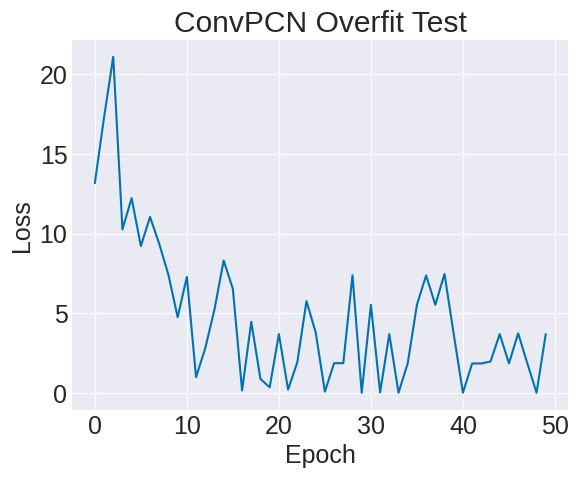

In [8]:

plt.plot(loss_history[0])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ConvPCN Overfit Test')
plt.show()

### 9b. Weight initialization and group norm CIAR-10 experiment

Let's run an experiment to see how the different weight initialization strategies (`'normal'` vs `'he'`) and group norm components of the model affect classification accuracy and speed of learning when training on CIFAR-10.

Train `ConvPC6Mini` with the following 3 configurations below:
1. Normal weight initialization, no group norm
2. He weight initialization, no group norm
3. He weight initialization, group norm

Make 3 high-quality plots to summarize the results of the simulation experiment:
1. training loss over epochs for the 3 nets.
2. val loss over epochs for the 3 nets.
3. val accuracy over epochs for the 3 nets.

Use default hyperparameters to train each of your networks except for:
- `30` training epochs.
- learning rate of `1e-4` (or try `1e-5` if network #2 does not make any training progress).

**Note:**
- When you import CIFAR-10, use the default `'global'` normalization approach.
- Remember that we are now training a CNN so you do NOT want to draw on the flattened features.
- Each network should take 5-10 minutes to train on the GPU.

In [9]:
import sys

sys.path.append("/content/drive/MyDrive/ColabNotebooks/CS446_Project2")

In [10]:
from image_datasets import get_dataset, train_val_split

x_train, y_train, x_test, y_test = get_dataset('cifar10',flatten=False)

x_train shape: (50000, 32, 32, 3), dtype: <dtype: 'float32'>
y_train shape: (50000,), dtype: <dtype: 'int32'>
x_test shape: (10000, 32, 32, 3), dtype: <dtype: 'float32'>
y_test shape: (10000,), dtype: <dtype: 'int32'>


In [11]:
x_train,y_train,x_val,y_val = train_val_split(x_train,y_train)
print(x_train.shape)

(45000, 32, 32, 3)


In [12]:
configs = [
    {"name": "normal_no_gn", "init": "normal", "group_norm": False},
    {"name": "he_no_gn", "init": "he", "group_norm": False},
    {"name": "he_gn", "init": "he", "group_norm": True},
]

In [13]:
def train_model(init_type, use_group_norm):
    model = ConvPCN6Mini(
        input_feats_shape=x_train.shape[1:],
        C=10,
        wt_init=init_type,
        do_group_norm=use_group_norm,
    )
    model.compile(lr = 1e-4)
    train_loss, val_loss, val_acc, _ = model.fit(
        x_train, y_train,
        x_val, y_val,
        batch_size=256,
        max_epochs=30,
    )

    return train_loss, val_loss, val_acc

In [14]:
results = {}

# normal_no_gn
cfg0 = configs[0]
print("Training: normal_no_gn")

train_loss0, val_loss0, val_acc0 = train_model(
    cfg0["init"],
    cfg0["group_norm"]
)

results["normal_no_gn"] = {
    "train_loss": train_loss0,
    "val_loss": val_loss0,
    "val_acc": val_acc0,
}




Training: normal_no_gn
---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 10]
Dense layer output(Dense_hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 3072]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(MaxPool_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2DTranspose layer output(PCNBlock_2_convT) shape: [1, 8, 8, 128]
	Conv2D layer output(PCNBlock_2_conv) shape: [1, 8, 8, 192]
MaxPool2D layer output(MaxPool_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2DTranspose layer output(PCNBlock_1_convT) shape: [1, 16, 16, 64]
	Conv2D layer output(PCNBlock_1_conv) shape: [1, 16, 16, 128]
MaxPool2D layer output(MaxPool_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2DTranspose layer output(PCNBlock_0_convT) shape: [1, 32, 32, 64]
	Conv2D layer output(PCNBlock_0_conv) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D_init) shape: [1, 32, 32, 64]
------------------------------------------------------

In [15]:
# he_no_gn
cfg1 = configs[1]
print("Training: he_no_gn")

train_loss1, val_loss1, val_acc1 = train_model(
    cfg1["init"],
    cfg1["group_norm"]
)

results["he_no_gn"] = {
    "train_loss": train_loss1,
    "val_loss": val_loss1,
    "val_acc": val_acc1,
}

Training: he_no_gn
---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 10]
Dense layer output(Dense_hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 3072]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(MaxPool_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2DTranspose layer output(PCNBlock_2_convT) shape: [1, 8, 8, 128]
	Conv2D layer output(PCNBlock_2_conv) shape: [1, 8, 8, 192]
MaxPool2D layer output(MaxPool_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2DTranspose layer output(PCNBlock_1_convT) shape: [1, 16, 16, 64]
	Conv2D layer output(PCNBlock_1_conv) shape: [1, 16, 16, 128]
MaxPool2D layer output(MaxPool_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2DTranspose layer output(PCNBlock_0_convT) shape: [1, 32, 32, 64]
	Conv2D layer output(PCNBlock_0_conv) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D_init) shape: [1, 32, 32, 64]
----------------------------------------------------------

In [16]:
import tensorflow as tf
tf.keras.backend.clear_session()
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [17]:
# he_gn
cfg2 = configs[2]
print("Training: he_gn")

train_loss2, val_loss2, val_acc2 = train_model(
    cfg2["init"],
    cfg2["group_norm"]
)

results["he_gn"] = {
    "train_loss": train_loss2,
    "val_loss": val_loss2,
    "val_acc": val_acc2,
}

Training: he_gn
---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 10]
Dense layer output(Dense_hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 3072]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(MaxPool_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2DTranspose layer output(PCNBlock_2_convT) shape: [1, 8, 8, 128]
	Conv2D layer output(PCNBlock_2_conv) shape: [1, 8, 8, 192]
MaxPool2D layer output(MaxPool_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2DTranspose layer output(PCNBlock_1_convT) shape: [1, 16, 16, 64]
	Conv2D layer output(PCNBlock_1_conv) shape: [1, 16, 16, 128]
MaxPool2D layer output(MaxPool_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2DTranspose layer output(PCNBlock_0_convT) shape: [1, 32, 32, 64]
	Conv2D layer output(PCNBlock_0_conv) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D_init) shape: [1, 32, 32, 64]
-------------------------------------------------------------

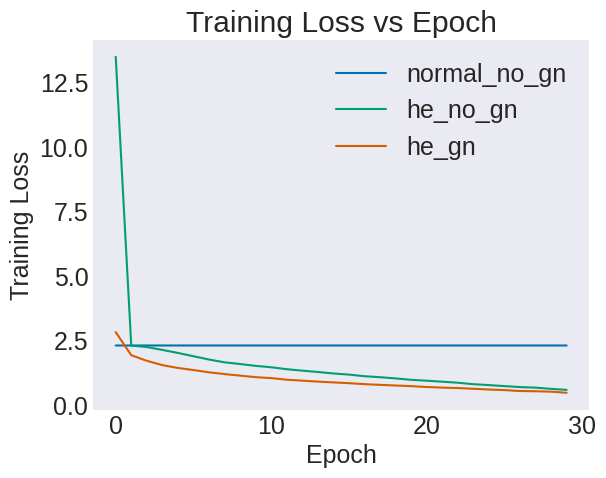

In [18]:
plt.figure()

for name in results:
    plt.plot(results[name]["train_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()

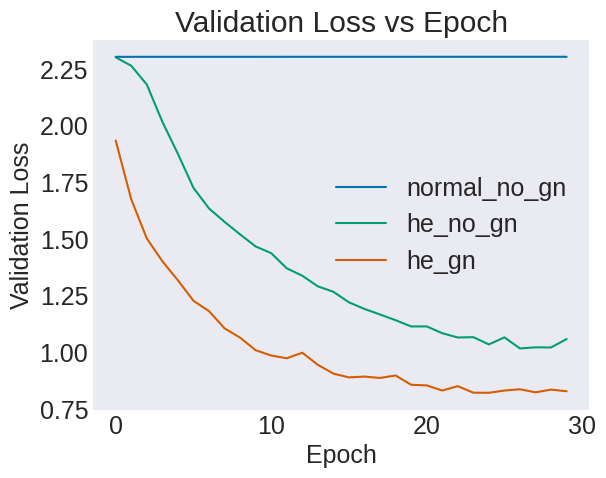

In [19]:
plt.figure()

for name in results:
    plt.plot(results[name]["val_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()

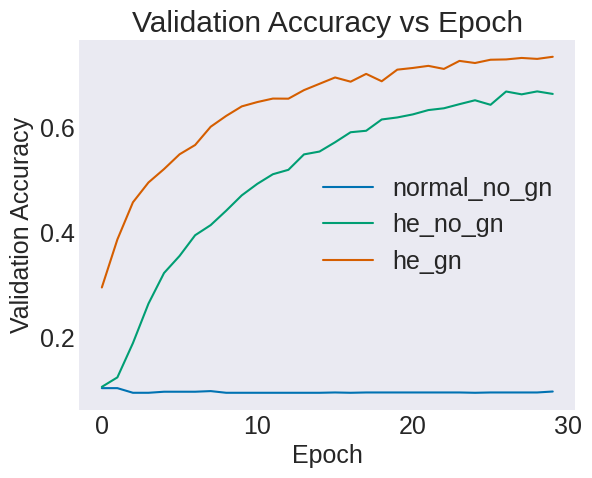

In [20]:
plt.figure()

for name in results:
    plt.plot(results[name]["val_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.grid()

plt.show()

## Task 10: Build, train, and evaluate larger ConvPCN on CIFAR-10

For fun, let's push the convolutional PCN architecture further and train an even larger net on CIFAR-10 that we will call `ConvPCN7XL` composed of the following:

- 1 solo `Conv2D` layer at the beginning of the network
- 4 ConvPCNBlocks
- 1 dense hidden layer
- 1 output layer

Your goal is to implement and train the network with default hyperparameters (including learning rate) except for the following:
- batch size of `64`
- patience of `7`
- learning rate patience of `3` (`3` max decays)
- Group norm and He initialization turned on

Make 2 high-quality plots showing
1. the training and validation loss over epochs
2. the validation acc over epochs

Print out the accuracy on the CIFAR-10 test set.

**Note:** This is expected to take some time to train, likely 60 mins+ on the GPU.


*Your network should do VERY well, way better than any network we have explored thus far!* 😊

In [21]:
from conv_pcn import ConvPCN7XL

In [22]:
big_model = ConvPCN7XL(
    input_feats_shape=x_train.shape[1:],
    C=10
)
big_model.compile(lr=1e-4)

---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 10]
Dense layer output(Dense_hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 16384]
Flatten layer output(Flatten) shape: [1, 16384]
MaxPool2D layer output(MaxPool_3) shape: [1, 8, 8, 256]
PCNBlock_3:
	Conv2DTranspose layer output(PCNBlock_3_convT) shape: [1, 16, 16, 256]
	Conv2D layer output(PCNBlock_3_conv) shape: [1, 16, 16, 256]
MaxPool2D layer output(MaxPool_2) shape: [1, 16, 16, 256]
PCNBlock_2:
	Conv2DTranspose layer output(PCNBlock_2_convT) shape: [1, 32, 32, 128]
	Conv2D layer output(PCNBlock_2_conv) shape: [1, 32, 32, 256]
PCNBlock_1:
	Conv2DTranspose layer output(PCNBlock_1_convT) shape: [1, 32, 32, 128]
	Conv2D layer output(PCNBlock_1_conv) shape: [1, 32, 32, 128]
PCNBlock_0:
	Conv2DTranspose layer output(PCNBlock_0_convT) shape: [1, 32, 32, 64]
	Conv2D layer output(PCNBlock_0_conv) shape: [1, 32, 32, 128]
Conv2D layer output(Conv2D_init) s

In [23]:
train_loss, val_loss, val_acc, _ = big_model.fit(
    x_train, y_train,
    x_val, y_val,
    batch_size=64,
    max_epochs=50,  # will stop early via patience
    patience=7,
    lr_patience=3,
    lr_max_decays=3,
)

Epoch 1/50 | Time : 441.19 s | train_loss: 2.0189 | val_loss: 1.5074 | val_acc: 0.4700

Epoch 2/50 | Time : 429.72 s | train_loss: 1.3477 | val_loss: 1.2064 | val_acc: 0.5785

Epoch 3/50 | Time : 429.61 s | train_loss: 1.1080 | val_loss: 1.0270 | val_acc: 0.6456

Epoch 4/50 | Time : 429.69 s | train_loss: 0.9497 | val_loss: 0.9466 | val_acc: 0.6729

Epoch 5/50 | Time : 429.78 s | train_loss: 0.8358 | val_loss: 0.8950 | val_acc: 0.6871

Epoch 6/50 | Time : 429.69 s | train_loss: 0.7460 | val_loss: 0.8558 | val_acc: 0.7155

Epoch 7/50 | Time : 429.76 s | train_loss: 0.6773 | val_loss: 0.8670 | val_acc: 0.7123

Epoch 8/50 | Time : 429.76 s | train_loss: 0.5981 | val_loss: 0.8686 | val_acc: 0.7173

Epoch 9/50 | Time : 429.81 s | train_loss: 0.5286 | val_loss: 0.8617 | val_acc: 0.7270
Learning rate decayed from 0.000100 to 0.000050.
 | LR decayed. Total decays: 1
Epoch 10/50 | Time : 429.77 s | train_loss: 0.3931 | val_loss: 0.8301 | val_acc: 0.7438

Epoch 11/50 | Time : 429.76 s | train_lo

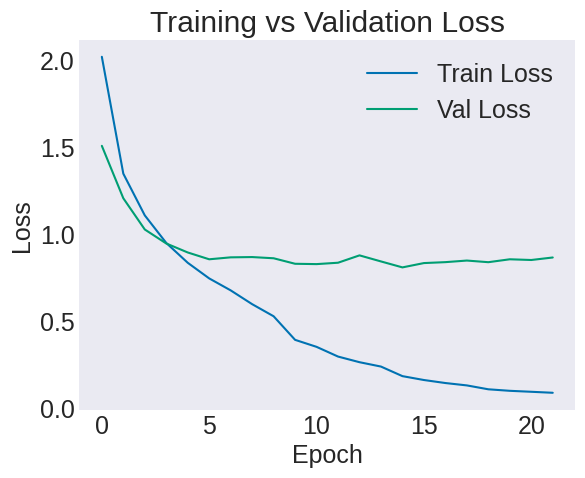

In [24]:

plt.figure()

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

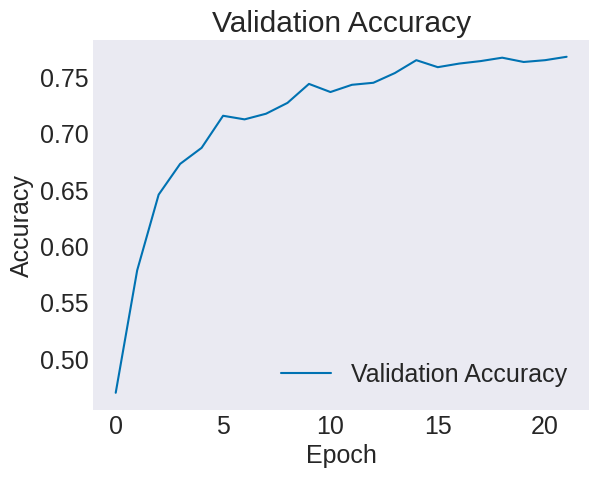

In [25]:
plt.figure()

plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [26]:
test_acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

NameError: name 'model' is not defined

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.**
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric).
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

#### 1. Explore other image completion scenarios

Explore the generative capability of the dense PCN more thoroughly by examining:
- quality of reconstruction when more/less is masked away.
- introduce different types of masks (e.g. horizontal, periodic stripes, etc.)
- try masking a random selection pixels. Analyze reconstruction with different proportions of the image that is masked out.
- try reconstructing image when random noise is added to the masked locations. Analyze reconstruction with different noise amounts/strengths.

#### 2. Nonlinearities in the dense PCN

*This is a challenging extension.*

The dense PCN is an entirely linear model. Modify the architecture to try different ways to incorporate nonlinearities (e.g. ReLU).

*This requires more thought than it might initially seem since ReLU 0s out signals and so they cannot be directly used to predict the signal below...*

#### 3. Dense PCN depth

You build a modular, extendable dense PCN, but in the base project we only considered nets with a single hidden layer. Run experiments to analyze how different depths/numbers of units affects classification accuracy, quality of dreaming, or quality of image completion.

#### 4. Hyperparameter exploration with ConvPCN

Can you find hyperparameters that produce even better CIFAR-10 validation accuracy?

*Given how time intensive it is to train the ConvPCNs I would suggest running focused experiments to analyze the effect of one/several hyperparameter while keeping most kept at default values.*

#### 5. Datasets of your choice

Train either the dense or convolutional PCN on a dataset of your choice. Characterize the accuracy or generative capabilities on your dataset.

Some good ones:
- MNIST
- Fashion MNIST
- CIFAR-100 (like CIFAR-10 but with 100 classes)

#### 6. Prediction error passes in the ConvPCN

Run an experiment that varies the number of steps for which each block attempts to minimize the local prediction error. Is there an optimal number?

#### 7. Modifying the ConvPCN architecture

Experiment with making changes to the ConvPCN architecture (add/remove max pooling layers, etc.).

#### 8. Runtime vs accuracy

Now that you have a high performing network try to build shallower/smaller networks that achieve as close accuracy to the deeper/larger ones, but train substantially faster. What trade offs do you make? How much does accuracy drop? How much time can you save?